# 04 - Đánh giá & So sánh mô hình (ĐÃ BỔ SUNG Cross-Validation + Baseline)
BTL môn Trí tuệ nhân tạo — Dữ liệu mô phỏng

## Bước 1: Load lại models, data test và kết quả Cross-Validation

In [1]:
import joblib
import pandas as pd

X_train, X_test, y_train, y_test = joblib.load("../data/processed/train_test_data.pkl")
feature_names = joblib.load("../data/processed/feature_names.pkl")

model_names = ["Dummy_Baseline", "Logistic_Regression", "Decision_Tree",
               "Random_Forest", "KNN", "SVM"]
models = {name: joblib.load(f"../results/models/{name}.pkl") for name in model_names}

cv_results_df = pd.read_csv("../results/cv_results.csv")
print(cv_results_df)

                 Model  F1_mean  F1_std  Accuracy_mean  Accuracy_std
0       Dummy_Baseline    0.788   0.000          0.650         0.000
1  Logistic_Regression    0.867   0.013          0.833         0.017
2        Decision_Tree    0.822   0.017          0.785         0.020
3        Random_Forest    0.856   0.022          0.817         0.028
4                  KNN    0.821   0.019          0.759         0.025
5                  SVM    0.866   0.015          0.832         0.021


## Bước 2: Đánh giá trên tập Test độc lập (Accuracy/Precision/Recall/F1)

In [2]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

detailed_results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    detailed_results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 3),
        "Precision_Do": round(precision_score(y_test, y_pred, pos_label=1, zero_division=0), 3),
        "Recall_Do": round(recall_score(y_test, y_pred, pos_label=1, zero_division=0), 3),
        "F1_Do": round(f1_score(y_test, y_pred, pos_label=1, zero_division=0), 3),
        "Precision_Truot": round(precision_score(y_test, y_pred, pos_label=0, zero_division=0), 3),
        "Recall_Truot": round(recall_score(y_test, y_pred, pos_label=0, zero_division=0), 3),
        "F1_Truot": round(f1_score(y_test, y_pred, pos_label=0, zero_division=0), 3),
    })

results_df = pd.DataFrame(detailed_results)
print(results_df)
results_df.to_csv("../results/comparison_table.csv", index=False)

                 Model  Accuracy  Precision_Do  Recall_Do  F1_Do  \
0       Dummy_Baseline     0.650         0.650      1.000  0.788   
1  Logistic_Regression     0.840         0.902      0.846  0.873   
2        Decision_Tree     0.777         0.848      0.800  0.823   
3        Random_Forest     0.847         0.882      0.882  0.882   
4                  KNN     0.823         0.835      0.908  0.870   
5                  SVM     0.847         0.907      0.851  0.878   

   Precision_Truot  Recall_Truot  F1_Truot  
0            0.000         0.000     0.000  
1            0.744         0.829     0.784  
2            0.664         0.733     0.697  
3            0.781         0.781     0.781  
4            0.795         0.667     0.725  
5            0.752         0.838     0.793  


## Bước 3: So sánh với Dummy Baseline — mốc tham chiếu bắt buộc
Nếu một mô hình không vượt trội hơn đáng kể so với Dummy Baseline, mô hình đó chưa thực sự "học" được điều gì có giá trị.

In [3]:
dummy_row = results_df[results_df["Model"] == "Dummy_Baseline"].iloc[0]
print(f"Dummy Baseline — Accuracy: {dummy_row['Accuracy']}, F1_Do: {dummy_row['F1_Do']}")
print()
for _, row in results_df.iterrows():
    if row["Model"] != "Dummy_Baseline":
        gain = row["F1_Do"] - dummy_row["F1_Do"]
        print(f"{row['Model']}: F1_Do = {row['F1_Do']} (chênh lệch so với baseline: {gain:+.3f})")

Dummy Baseline — Accuracy: 0.65, F1_Do: 0.788

Logistic_Regression: F1_Do = 0.873 (chênh lệch so với baseline: +0.085)
Decision_Tree: F1_Do = 0.823 (chênh lệch so với baseline: +0.035)
Random_Forest: F1_Do = 0.882 (chênh lệch so với baseline: +0.094)
KNN: F1_Do = 0.87 (chênh lệch so với baseline: +0.082)
SVM: F1_Do = 0.878 (chênh lệch so với baseline: +0.090)


## Bước 4: classification_report chi tiết

In [4]:
from sklearn.metrics import classification_report

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"===== {name} =====")
    print(classification_report(y_test, y_pred, target_names=["Trượt", "Đỗ"], zero_division=0))

===== Dummy_Baseline =====
              precision    recall  f1-score   support

       Trượt       0.00      0.00      0.00       105
          Đỗ       0.65      1.00      0.79       195

    accuracy                           0.65       300
   macro avg       0.33      0.50      0.39       300
weighted avg       0.42      0.65      0.51       300

===== Logistic_Regression =====
              precision    recall  f1-score   support

       Trượt       0.74      0.83      0.78       105
          Đỗ       0.90      0.85      0.87       195

    accuracy                           0.84       300
   macro avg       0.82      0.84      0.83       300
weighted avg       0.85      0.84      0.84       300

===== Decision_Tree =====
              precision    recall  f1-score   support

       Trượt       0.66      0.73      0.70       105
          Đỗ       0.85      0.80      0.82       195

    accuracy                           0.78       300
   macro avg       0.76      0.77      0.76

## Bước 5: Confusion Matrix

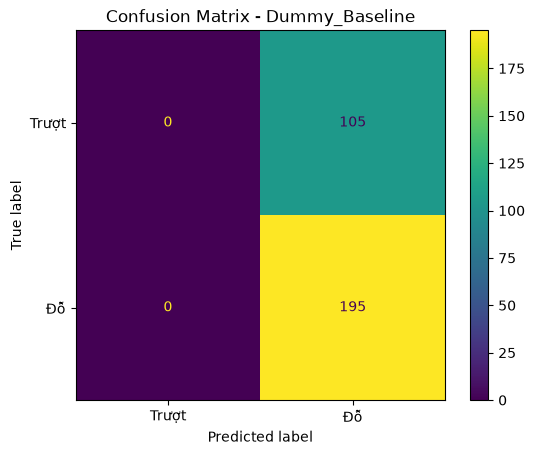

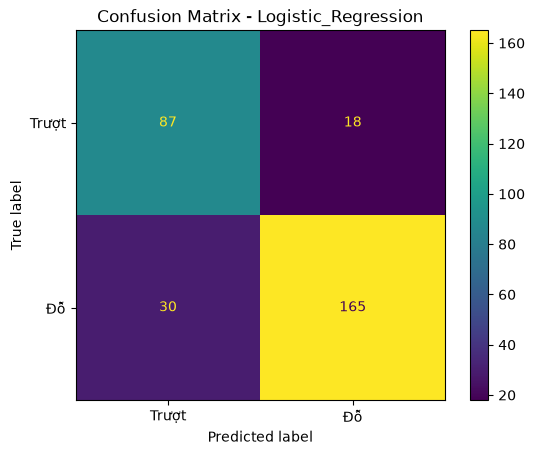

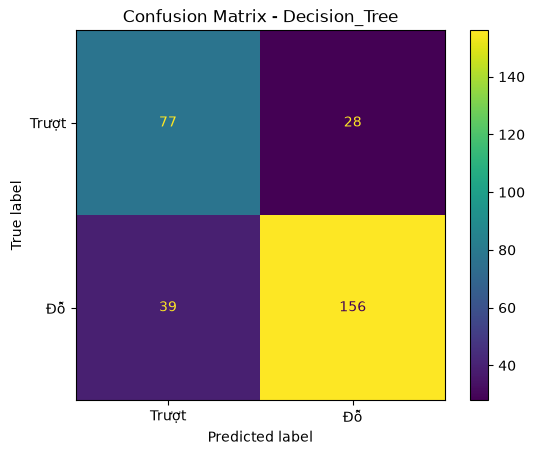

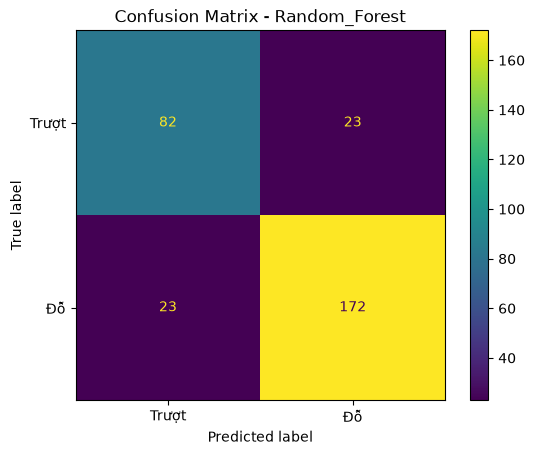

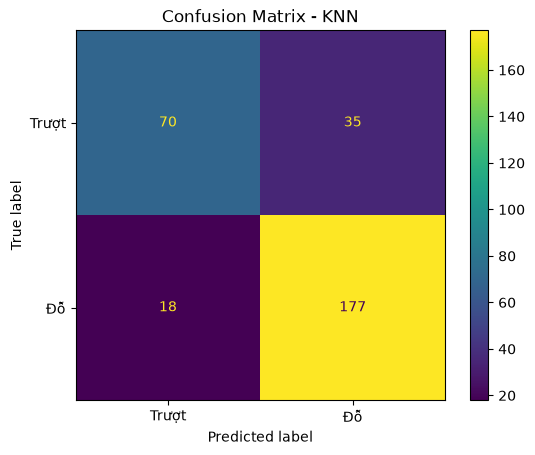

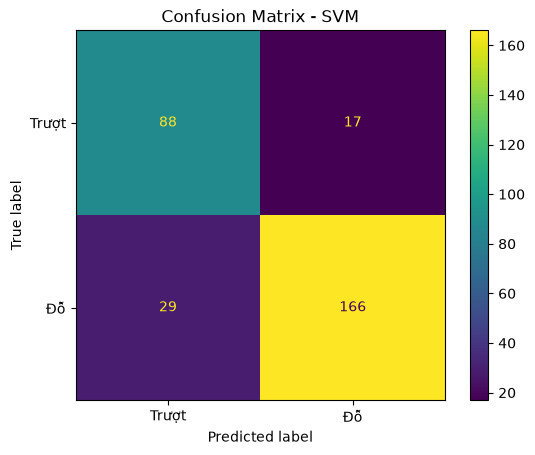

In [5]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os

os.makedirs("../results/figures", exist_ok=True)

for name, model in models.items():
    y_pred = model.predict(X_test)
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Trượt", "Đỗ"])
    plt.title(f"Confusion Matrix - {name}")
    plt.savefig(f"../results/figures/cm_{name}.png")
    plt.show()

## Bước 6: ROC Curve so sánh

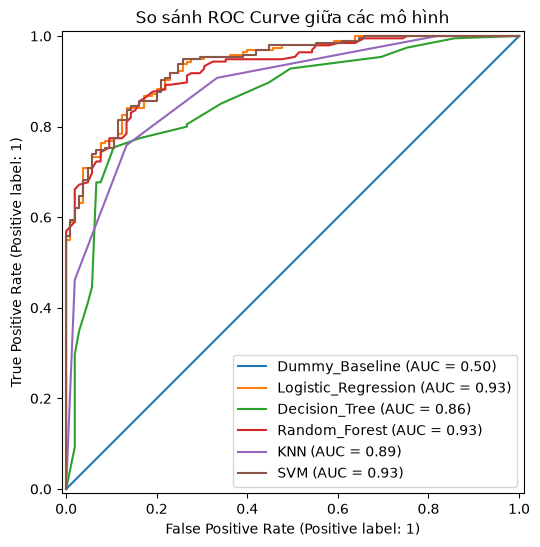

In [6]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))
for name, model in models.items():
    if hasattr(model, "predict_proba"):
        RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)
plt.title("So sánh ROC Curve giữa các mô hình")
plt.savefig("../results/figures/roc_comparison.png")
plt.show()

## Bước 7: Feature Importance (Random Forest)

             Feature  Importance
4     HocLucNamTruoc    0.252694
6    GioTuHocMoiTuan    0.217500
5      TiLeChuyenCan    0.201558
9  ThoiGianMangXaHoi    0.145481
2        HocVanChaMe    0.049252
3    HoanCanhGiaDinh    0.032935
7     ThamGiaHocThem    0.031582
8         OnThiTruoc    0.027445
1     KhuVucSinhSong    0.021775
0           GioiTinh    0.019779


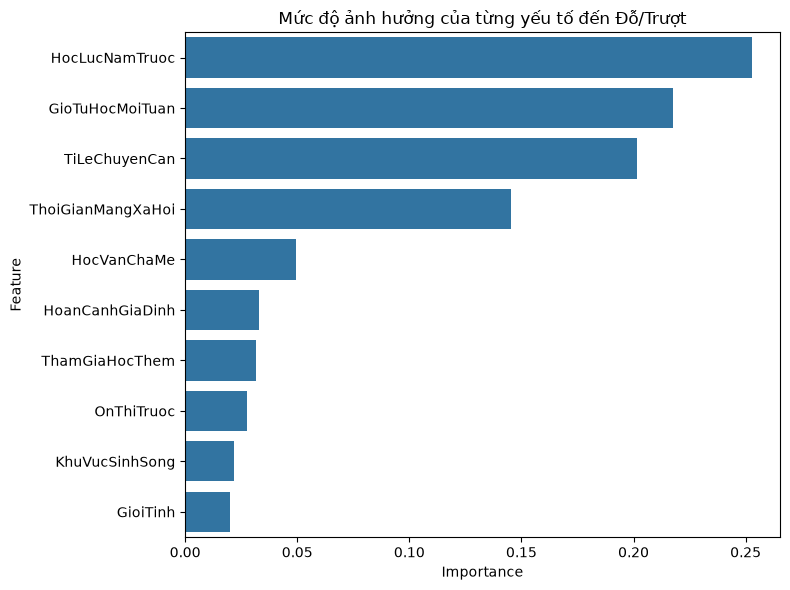

In [7]:
import seaborn as sns

rf_model = models["Random_Forest"]
importances = rf_model.feature_importances_

feat_df = pd.DataFrame({"Feature": feature_names, "Importance": importances})
feat_df = feat_df.sort_values(by="Importance", ascending=False)
print(feat_df)

plt.figure(figsize=(8, 6))
sns.barplot(data=feat_df, x="Importance", y="Feature")
plt.title("Mức độ ảnh hưởng của từng yếu tố đến Đỗ/Trượt")
plt.tight_layout()
plt.savefig("../results/figures/feature_importance.png")
plt.show()

## Bước 8: Bảng tổng hợp cuối — Test-set score kèm Cross-Validation mean ± std
Đây là bảng đầy đủ nhất để đưa vào báo cáo/slide — thỏa mãn yêu cầu "báo cáo cả giá trị trung bình và độ phân tán qua các lần gấp của kiểm chứng chéo".

In [8]:
final_table = results_df.merge(cv_results_df, on="Model")
final_table = final_table[["Model", "Accuracy", "F1_Do", "Accuracy_mean", "Accuracy_std",
                            "F1_mean", "F1_std"]]
print(final_table)
final_table.to_csv("../results/final_summary_table.csv", index=False)

                 Model  Accuracy  F1_Do  Accuracy_mean  Accuracy_std  F1_mean  \
0       Dummy_Baseline     0.650  0.788          0.650         0.000    0.788   
1  Logistic_Regression     0.840  0.873          0.833         0.017    0.867   
2        Decision_Tree     0.777  0.823          0.785         0.020    0.822   
3        Random_Forest     0.847  0.882          0.817         0.028    0.856   
4                  KNN     0.823  0.870          0.759         0.025    0.821   
5                  SVM     0.847  0.878          0.832         0.021    0.866   

   F1_std  
0   0.000  
1   0.013  
2   0.017  
3   0.022  
4   0.019  
5   0.015  
